In [1]:
import os
import xarray as xr
import sys
import itertools
from itertools import zip_longest
from lca_algebraic import initProject
import pandas as pd
import numpy as np
import xarray as xr
import pickle
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches
plt.rcParams['font.family'] = 'Times New Roman'
plt.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid

## 1. get LCA results from each module 

In [2]:
ds_v1 = xr.open_dataset('../pGWP_module_output/V1AB_init_ICEVGT_pGWP100.nc')
ds_f2 = xr.open_dataset('../pGWP_module_output/F2_ICEVdGT_pGWP100.nc')
ds_v2 = xr.open_dataset('../pGWP_module_output/V2_ICEVdGT_pGPW100.nc') 

In [3]:
#ds_v2

In [4]:
#combined_ds = xr.concat([ds_v1['value'], ds_f2['value'], ds_v2['value']], dim='Impact_category')
#dscc = combined_ds.to_dataset()
#dscc.sel(tech_list = "dummy_tech", SSP = 'ssp119', v_year = 2040, v_module = 'F2_fuel_d')

In [5]:
df_list = []
for sp in ds_v1.SSP.values:
    for vy in ds_v1.v_year.values: 
        IC =  ds_v1.Impact_category.values 
        vy_col = [vy] * len(ds_v1.v_year.values)
        sp_col = [sp] * len(ds_v1.SSP.values)
        v2_score = ds_f2.sel(tech_list = "dummy_tech", SSP = sp, v_year = vy, v_module = 'F2_fuel_d')['value'].values
        f2_score = ds_v2.sel(tech_list = "dummy_tech", SSP = sp, v_year = vy, v_module = 'V2_oper_EF')['value'].values
        v1_score = ds_v1.sel(tech_list = "dummy_tech", SSP = sp, v_year = vy, v_module = 'V1AB_init')['value'].values
        df_colname = ["SSP", "v_year", "IC", "V1A", "F2", "V2" ]
        df = pd.DataFrame(zip(sp_col, vy_col, IC, v1_score,v2_score,f2_score), columns = df_colname)
        df_list.append(df)

In [6]:
icev_df = pd.concat(df_list, ignore_index=True)
#icev_df2 = icev_df[icev_df["IC"] != 'IPCC2021_default']

In [33]:
98438.795525 +	215204.681141	+ 925337.088000

1238980.564666

In [32]:
icev_df

,SSP,v_year,IC,V1A,F2,V2
0,ssp119,2030,IPCC2021_default,98438.795525,215204.681141,925337.088000
1,ssp119,2030,pGWP100,99125.053226,26768.625653,922867.545960
2,ssp119,2030,premise_GWP,101192.073576,41166.370829,925337.088000
3,ssp119,2040,IPCC2021_default,87588.259380,176013.923959,879070.233600
4,ssp119,2040,pGWP100,87556.976391,-480508.620881,876671.642052
5,ssp119,2040,premise_GWP,88860.703452,-471021.921025,879070.233600
6,ssp119,2050,IPCC2021_default,84479.855746,145735.217402,835116.721920
7,ssp119,2050,pGWP100,82663.226564,-858523.524094,832677.228951
8,ssp119,2050,premise_GWP,83778.524593,-850454.024100,835116.721920
9,ssp245,2030,IPCC2021_default,114930.409045,236462.629659,925337.088000


## plot 

In [17]:

import matplotlib.ticker as ticker

def format_yticks(value, pos):
        return f'{int(value/1e5)}e5' if value >= 1e5 else str(int(value))
    

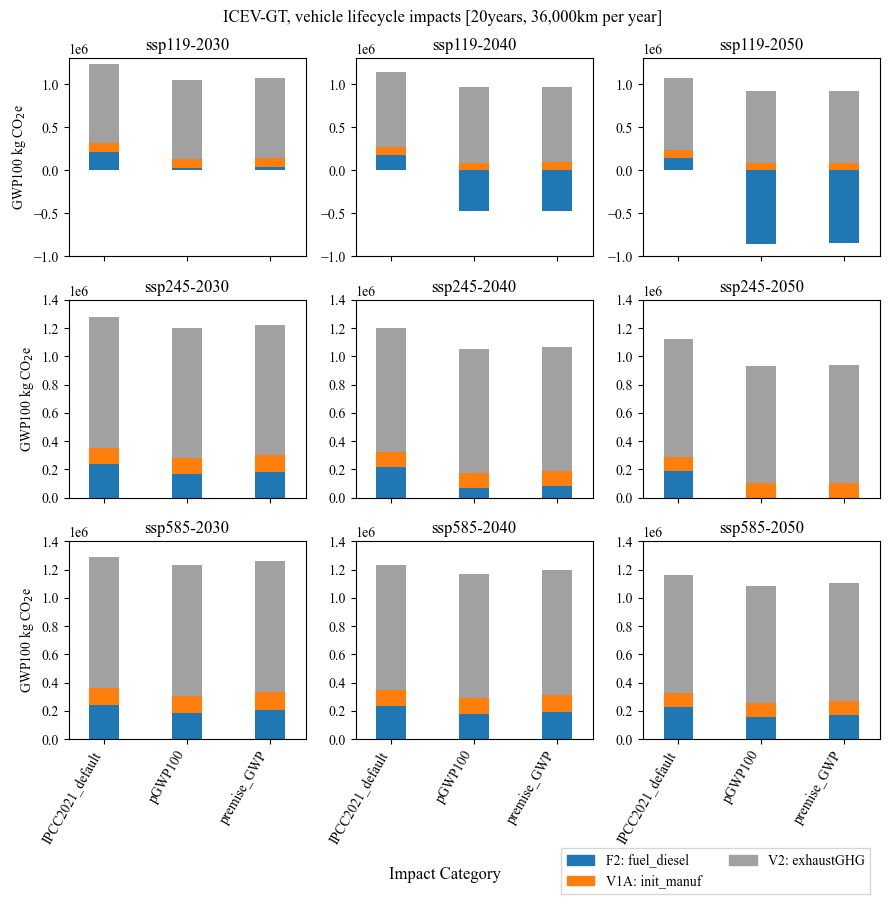

In [31]:
color_dict = {
    'F2':  '#1f77b4',   # blue
    'V1A': '#ff7f0e',  # Orange
    'V2': '0.63',   # Medium gray
}

fig, axs = plt.subplots(3, 3, figsize=(9, 9))

axs = axs.flatten()
for i in range(len(df_list)) :
    ax = axs[i]
    axs[i].grid(True, linestyle='--', linewidth=0.5, color='gray')

    df = df_list[i]
    ddf = df[['IC', 'V1A', 'F2', 'V2']]    
    pivot_df = ddf.pivot_table(index='IC', columns='IC', values= ['V1A', 'F2', 'V2' ] )# , aggfunc='sum')
    colors = [color_dict[col[0]] for col in pivot_df.columns]
    subtitle = str(df["SSP"][0]) + "-" + str(df["v_year"][0] )
    pivot_df.plot(kind='bar', ax=ax, stacked=True, legend=False, color=colors, title =subtitle, width=0.36, xlabel='' )
    axs[i].set_title(subtitle)

    # for ylables
    if i == 0 : 
        axs[i].set_ylabel(r'GWP100 kg CO$_2$e')
        axs[i].set_ylim(-1e6, 1.3e6)
    elif i == 1 or i == 2: 
        axs[i].set_ylabel('') 
        axs[i].set_ylim(-1e6, 1.3e6)
    elif i % 3 != 0:  
        axs[i].set_ylabel('') 
    else: 
        axs[i].set_ylabel(r'GWP100 kg CO$_2$e')

    if i == 3  or i == 4 or i == 5 or i == 6  or i == 7 or i == 8: 
        axs[i].set_ylim(0, 1.4e6)

    
    # for xlables    
    if i<6:
        axs[i].set_xticklabels([])  
        axs[i].set_xlabel('') 
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')


# Add labels and title
fig.suptitle('ICEV-GT, vehicle lifecycle impacts [20years, 36,000km per year] ')
handles = [mpatches.Patch(color=color_dict['F2'], label='F2: fuel_diesel'),
           mpatches.Patch(color=color_dict['V1A'], label='V1A: init_manuf'),
           mpatches.Patch(color=color_dict['V2'], label='V2: exhaustGHG')]
fig.legend(handles=handles, loc='lower right', bbox_to_anchor=(0.98, -0.01), fancybox=False, ncol=2)

plt.xlabel("")
fig.supxlabel('Impact Category')
plt.tight_layout()
plt.show()

In [35]:
icev_df

,SSP,v_year,IC,V1A,F2,V2
0,ssp119,2030,IPCC2021_default,98438.795525,215204.681141,925337.088000
1,ssp119,2030,pGWP100,99125.053226,26768.625653,922867.545960
2,ssp119,2030,premise_GWP,101192.073576,41166.370829,925337.088000
3,ssp119,2040,IPCC2021_default,87588.259380,176013.923959,879070.233600
4,ssp119,2040,pGWP100,87556.976391,-480508.620881,876671.642052
5,ssp119,2040,premise_GWP,88860.703452,-471021.921025,879070.233600
6,ssp119,2050,IPCC2021_default,84479.855746,145735.217402,835116.721920
7,ssp119,2050,pGWP100,82663.226564,-858523.524094,832677.228951
8,ssp119,2050,premise_GWP,83778.524593,-850454.024100,835116.721920
9,ssp245,2030,IPCC2021_default,114930.409045,236462.629659,925337.088000


In [36]:
icev_df.to_excel("output/ICEV_vlifecycle_finalLCA.xlsx", index= False)